# **10x Visium colon metabolic crosstalk robustness analysis**

In [1]:
import harreman
import os
import numpy as np
import pandas as pd
import anndata as ad
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.multitest import multipletests
from sklearn.mixture import GaussianMixture
from itertools import product, combinations
from plotnine import *
import warnings
warnings.filterwarnings("ignore")

## Visium colon dataset

In [2]:
BASE_PATH = "/home/projects/nyosef/oier/Harreman_files/Visium_colon"
ADATA_PATH = os.path.join(BASE_PATH, 'h5ads')
DATA_PATH = os.path.join(BASE_PATH, 'data')
PLOTS_PATH = os.path.join(BASE_PATH, 'plots')

In [3]:
adata = harreman.read_h5ad(os.path.join(ADATA_PATH, 'Visium_colon_Harreman_unrolled.h5ad'))

### Pairwise correlation (number of neighbors)

In [4]:
n_neighbors_values = [5, 10, 15, 20, 25, 30, 35, 40, 45, 50]

In [5]:
def metabolite_pairwise_correlation_n_neighbors_robustness_pipeline(adata, n_neighbors):

    harreman.pp.extract_interaction_db(adata, species='mouse', database='both')
    
    harreman.tl.compute_knn_graph(adata, 
                           compute_neighbors_on_key="spatial_unrolled", 
                           n_neighbors=n_neighbors,
                           weighted_graph=False,
                           sample_key='cond')
    
    harreman.tl.compute_gene_pairs(adata, ct_specific = False)

    harreman.tl.compute_cell_communication(adata, model='danb', M = 1000, test = "both", layer_key_p_test='counts', layer_key_np_test='log_norm')

    harreman.tl.select_significant_interactions(adata, test = "non-parametric", threshold = 0.05)
    
    cell_com_df_gp = adata.uns['ccc_results']['cell_com_df_gp']
    cell_com_df_m = adata.uns['ccc_results']['cell_com_df_m']

    return cell_com_df_gp, cell_com_df_m

In [6]:
def compute_significant_event_jaccard(dictionary):
    
    jaccard_sim_matrix = np.zeros((len(dictionary.keys()), len(dictionary.keys())))
    for i in range(len(dictionary.keys())):
        for j in range(len(dictionary.keys())):
            key_i = list(dictionary.keys())[i]
            key_j = list(dictionary.keys())[j]
            a = dictionary[key_i]
            b = dictionary[key_j]
            jaccard_sim_matrix[i,j] = len(list(set(a) & set(b))) / len(list(set(a) | set(b)))
    jaccard_sim_matrix_df = pd.DataFrame(jaccard_sim_matrix, index=dictionary.keys(), columns=dictionary.keys())
    
    return jaccard_sim_matrix_df

In [7]:
def compute_event_correlation(dictionary):
    
    corr_df = pd.concat(dictionary, axis=1, join="inner").corr()
    
    return corr_df

In [8]:
def to_str(x):
    if isinstance(x, list):
        return "_".join(map(str, x))
    return str(x)

In [9]:
significant_gene_pairs_dict = {}
significant_metabolites_dict = {}
gene_pairs_z_scores_dict = {}
metabolites_z_scores_dict = {}
for n_neighbors in n_neighbors_values:
    print(n_neighbors)
    cell_com_df_gp, cell_com_df_m = metabolite_pairwise_correlation_n_neighbors_robustness_pipeline(adata, n_neighbors)
    cell_com_df_gp = cell_com_df_gp.copy()
    cell_com_df_m = cell_com_df_m.copy()
    cell_com_df_gp.index = (cell_com_df_gp["Gene 1"].apply(to_str) + "_" + cell_com_df_gp["Gene 2"].apply(to_str))
    cell_com_df_m = cell_com_df_m.set_index('Metabolite')
    significant_gene_pairs_dict[n_neighbors] = cell_com_df_gp[cell_com_df_gp['selected']].index.tolist()
    significant_metabolites_dict[n_neighbors] = cell_com_df_m[cell_com_df_m['selected']].index.tolist()
    gene_pairs_z_scores_dict[n_neighbors] = cell_com_df_gp['Z']
    metabolites_z_scores_dict[n_neighbors] = cell_com_df_m['Z']

5


Permutation test: 100%|██████████| 1000/1000 [00:37<00:00, 26.60it/s]


10


Permutation test: 100%|██████████| 1000/1000 [00:41<00:00, 24.20it/s]


15


...

Permutation test: 100%|██████████| 1000/1000 [00:59<00:00, 16.68it/s]


45


Permutation test: 100%|██████████| 1000/1000 [01:02<00:00, 16.00it/s]


50


Permutation test: 100%|██████████| 1000/1000 [01:05<00:00, 15.26it/s]


In [10]:
gp_jaccard_sim_matrix_df = compute_significant_event_jaccard(significant_gene_pairs_dict)
m_jaccard_sim_matrix_df = compute_significant_event_jaccard(significant_metabolites_dict)

gp_cor_matrix_df = compute_event_correlation(gene_pairs_z_scores_dict)
m_cor_matrix_df = compute_event_correlation(metabolites_z_scores_dict)

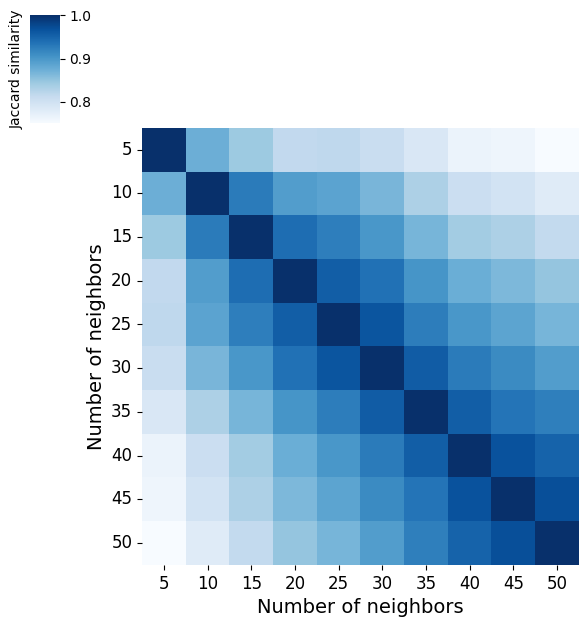

In [14]:
cm = sns.clustermap(data=gp_jaccard_sim_matrix_df, row_cluster=False, col_cluster=False, cmap='Blues', figsize=(6,6), vmin=0.75)
ax = cm.ax_heatmap
ax.set_xlabel('Number of neighbors', fontsize=14)
ax.set_ylabel('Number of neighbors', fontsize=14)
ax.set_xticklabels(ax.get_xticklabels(), fontsize=12)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=12)

ax.yaxis.set_ticks_position("left")
ax.yaxis.set_label_position("left")

fig = plt.gcf()

min_delta = 1e99
min_aa = None
for aa in fig.get_children():
    try:
        bbox = aa.get_position()
        delta = (0-bbox.xmin)**2 + (1-bbox.ymax)**2
        if delta < min_delta:
            delta = min_delta
            min_aa = aa
    except AttributeError:
        pass

min_aa.set_ylabel('Jaccard similarity')
min_aa.yaxis.set_label_position("left")

plt.savefig(os.path.join(PLOTS_PATH, 'gp_n_neighbors_jaccard_cluster_map.svg'))

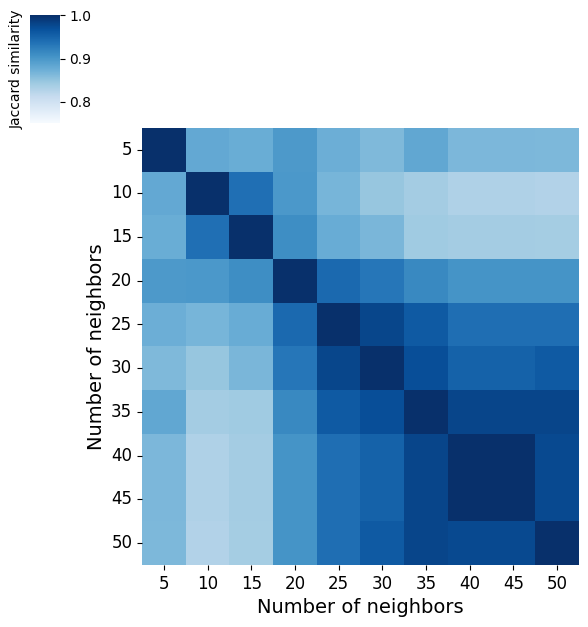

In [15]:
cm = sns.clustermap(data=m_jaccard_sim_matrix_df, row_cluster=False, col_cluster=False, cmap='Blues', figsize=(6,6), vmin=0.75)
ax = cm.ax_heatmap
ax.set_xlabel('Number of neighbors', fontsize=14)
ax.set_ylabel('Number of neighbors', fontsize=14)
ax.set_xticklabels(ax.get_xticklabels(), fontsize=12)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=12)

ax.yaxis.set_ticks_position("left")
ax.yaxis.set_label_position("left")

fig = plt.gcf()

min_delta = 1e99
min_aa = None
for aa in fig.get_children():
    try:
        bbox = aa.get_position()
        delta = (0-bbox.xmin)**2 + (1-bbox.ymax)**2
        if delta < min_delta:
            delta = min_delta
            min_aa = aa
    except AttributeError:
        pass

min_aa.set_ylabel('Jaccard similarity')
min_aa.yaxis.set_label_position("left")

plt.savefig(os.path.join(PLOTS_PATH, 'metab_n_neighbors_jaccard_cluster_map.svg'))

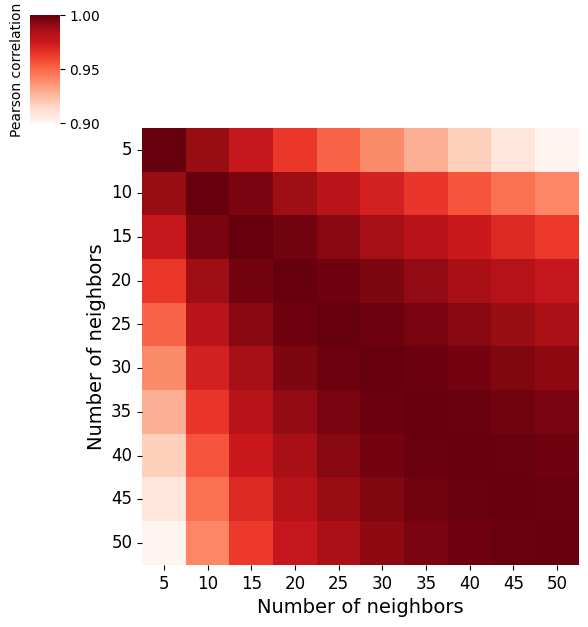

In [20]:
cm = sns.clustermap(data=gp_cor_matrix_df, row_cluster=False, col_cluster=False, cmap='Reds', figsize=(6,6), vmin=0.9)
ax = cm.ax_heatmap
ax.set_xlabel('Number of neighbors', fontsize=14)
ax.set_ylabel('Number of neighbors', fontsize=14)
ax.set_xticklabels(ax.get_xticklabels(), fontsize=12)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=12)

ax.yaxis.set_ticks_position("left")
ax.yaxis.set_label_position("left")

fig = plt.gcf()

min_delta = 1e99
min_aa = None
for aa in fig.get_children():
    try:
        bbox = aa.get_position()
        delta = (0-bbox.xmin)**2 + (1-bbox.ymax)**2
        if delta < min_delta:
            delta = min_delta
            min_aa = aa
    except AttributeError:
        pass

min_aa.set_ylabel('Pearson correlation')
min_aa.yaxis.set_label_position("left")

plt.savefig(os.path.join(PLOTS_PATH, 'gp_n_neighbors_pearson_cluster_map.svg'))

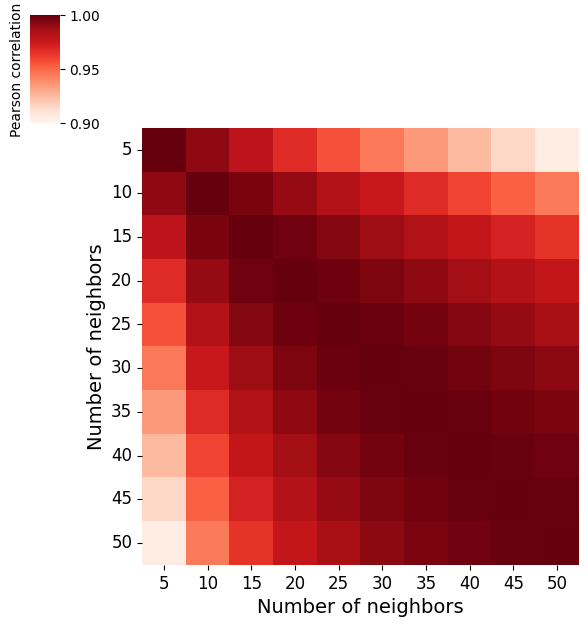

In [21]:
cm = sns.clustermap(data=m_cor_matrix_df, row_cluster=False, col_cluster=False, cmap='Reds', figsize=(6,6), vmin=0.9)
ax = cm.ax_heatmap
ax.set_xlabel('Number of neighbors', fontsize=14)
ax.set_ylabel('Number of neighbors', fontsize=14)
ax.set_xticklabels(ax.get_xticklabels(), fontsize=12)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=12)

ax.yaxis.set_ticks_position("left")
ax.yaxis.set_label_position("left")

fig = plt.gcf()

min_delta = 1e99
min_aa = None
for aa in fig.get_children():
    try:
        bbox = aa.get_position()
        delta = (0-bbox.xmin)**2 + (1-bbox.ymax)**2
        if delta < min_delta:
            delta = min_delta
            min_aa = aa
    except AttributeError:
        pass

min_aa.set_ylabel('Pearson correlation')
min_aa.yaxis.set_label_position("left")

plt.savefig(os.path.join(PLOTS_PATH, 'metab_n_neighbors_pearson_cluster_map.svg'))

### FDR CDF plots

In [15]:
def empirical_cdf(x):
    x_sorted = np.sort(x)
    y = np.arange(1, len(x_sorted) + 1) / len(x_sorted)
    return x_sorted, y

In [56]:
def visualize_results(x1_sorted, x2_sorted, y1, y2, title):
    plt.figure(figsize=(5, 5))
    plt.step(x1_sorted, y1, where="post", label='Parametric test', linewidth=2, color='#252525')
    plt.step(x2_sorted, y2, where="post", label='Non-parametric test', linewidth=2, color='#6BAED6')
    
    plt.vlines(
        0.05,
        0,
        1,
        linestyles="dashed",
        colors="#737373",
        label="FDR = 0.05"
    )

    plt.xlabel("FDR", fontsize=14)
    plt.ylabel("Empirical CDF", fontsize=14)
    plt.title(title, fontsize=16)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.legend(fontsize=12)
    plt.grid(alpha=0.3)
    plt.tight_layout()

#### Metabolic Hotspot

In [64]:
adata = ad.read_h5ad(os.path.join(ADATA_PATH, 'Visium_colon_unrolled_adata.h5ad'))

In [65]:
sample_col = 'cond'
n_genes_expr = 50
genes_to_keep = np.zeros(adata.shape[1], dtype=bool)

for sample in adata.obs[sample_col].unique():
    adata_sample = adata[adata.obs[sample_col] == sample]
    expressed = np.array((adata_sample.X > 0).sum(axis=0)).flatten()
    genes_to_keep |= expressed >= n_genes_expr

adata = adata[:, genes_to_keep].copy()

In [66]:
harreman.tl.compute_knn_graph(adata, 
                           compute_neighbors_on_key="spatial_unrolled", 
                           n_neighbors=5,
                           weighted_graph=False,
                           sample_key='cond',
                           verbose=True)

Computing the neighborhood graph...
Restricting graph within samples using 'cond'...


100%|██████████| 2/2 [00:00<00:00, 95.93it/s]

Computing the weights...
Finished computing the KNN graph in 0.045 seconds


In [67]:
harreman.hs.compute_local_autocorrelation(adata, layer_key="counts", model='danb', species='mouse', use_metabolic_genes=True, permutation_test=True, verbose=True)

Computing local autocorrelation...


Permutation test: 100%|██████████| 1000/1000 [00:03<00:00, 326.69it/s]

Local autocorrelation results are stored in adata.uns['gene_autocorrelation_results']
Finished computing local autocorrelation in 3.333 seconds


In [68]:
x1 = adata.uns['gene_autocorrelation_results']['Z_FDR'].dropna().values
x2 = adata.uns['gene_autocorrelation_results']['Perm_FDR'].dropna().values

x1_sorted, y1 = empirical_cdf(x1)
x2_sorted, y2 = empirical_cdf(x2)

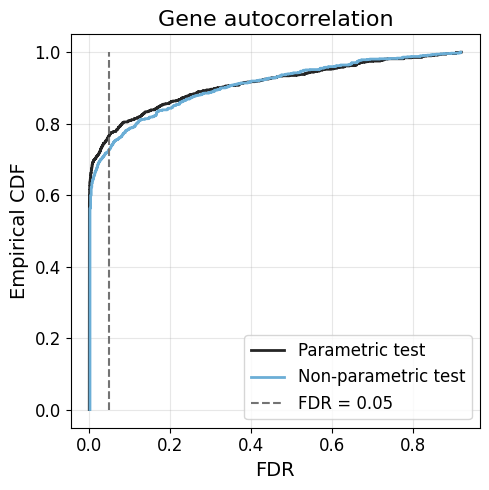

In [69]:
visualize_results(x1_sorted, x2_sorted, y1, y2, title='Gene autocorrelation')
plt.savefig(f'{PLOTS_PATH}/gene_autocorrelation_FDR_CDF_plot.svg')
plt.show()

In [70]:
gene_autocorrelation_results = adata.uns['gene_autocorrelation_results']
genes = gene_autocorrelation_results.loc[gene_autocorrelation_results.Z_FDR < 0.01].sort_values('Z', ascending=False).index

In [71]:
harreman.hs.compute_local_correlation(adata, genes=genes, permutation_test=True, verbose=True, device='cpu')

Computing pair-wise local correlation on 759 features...


Permutation test: 100%|██████████| 1000/1000 [01:31<00:00, 10.98it/s]


Pair-wise local correlation results are stored in adata.uns with the following keys: ['lc_perm_pvals', 'lc_perm_pvals_sym', 'lcs', 'lc_zs', 'lc_z_pvals', 'lc_z_FDR']
Finished computing pair-wise local correlation in 91.702 seconds


In [72]:
x1 = adata.uns['lc_z_FDR'].values.flatten()
x2 = multipletests(adata.uns['lc_perm_pvals'].values.flatten(), method="fdr_bh")[1]

x1_sorted, y1 = empirical_cdf(x1)
x2_sorted, y2 = empirical_cdf(x2)

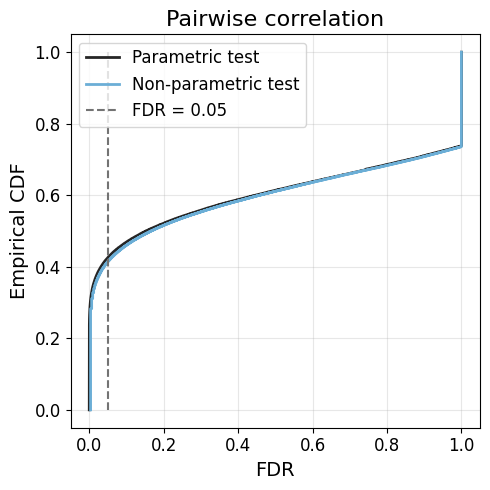

In [73]:
visualize_results(x1_sorted, x2_sorted, y1, y2, title='Pairwise correlation')
plt.savefig(f'{PLOTS_PATH}/pairwise_correlation_FDR_CDF_plot.svg')
plt.show()

#### ct-agnostic Harreman

In [46]:
adata = harreman.read_h5ad(os.path.join(ADATA_PATH, 'Visium_colon_Harreman_unrolled.h5ad'))

In [59]:
cell_com_df_gp = adata.uns['ccc_results']['cell_com_df_gp'].copy()
cell_com_df_m = adata.uns['ccc_results']['cell_com_df_m'].copy()

#### Gene pairs

In [60]:
x1 = cell_com_df_gp['Z_FDR'].dropna().values
x2 = cell_com_df_gp['FDR_np'].dropna().values

x1_sorted, y1 = empirical_cdf(x1)
x2_sorted, y2 = empirical_cdf(x2)

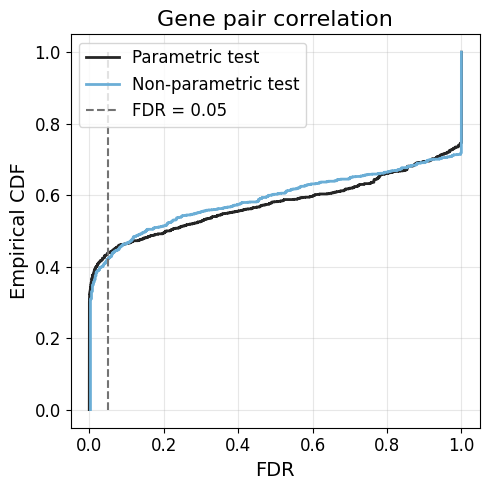

In [61]:
visualize_results(x1_sorted, x2_sorted, y1, y2, title='Gene pair correlation')
plt.savefig(f'{PLOTS_PATH}/gp_correlation_FDR_CDF_plot.svg')
plt.show()

#### Metabolites

In [62]:
x1 = cell_com_df_m['Z_FDR'].dropna().values
x2 = cell_com_df_m['FDR_np'].dropna().values

x1_sorted, y1 = empirical_cdf(x1)
x2_sorted, y2 = empirical_cdf(x2)

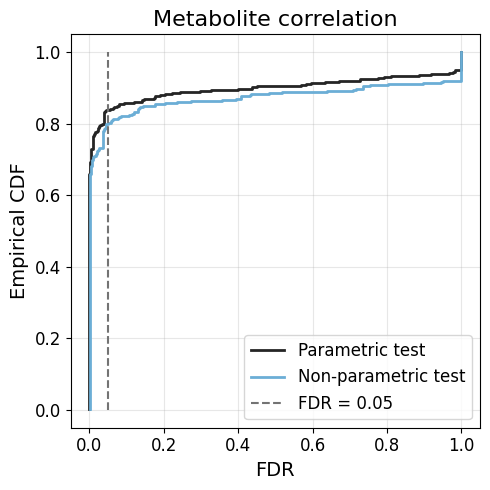

In [63]:
visualize_results(x1_sorted, x2_sorted, y1, y2, title='Metabolite correlation')
plt.savefig(f'{PLOTS_PATH}/metab_correlation_FDR_CDF_plot.svg')
plt.show()

### Pairwise correlation (threshold)

In [4]:
threshold_values = [0, 0.5, 1, 1.5, 2, 2.5]
ref_value = 1

In [5]:
def metabolite_pairwise_correlation_threshold_robustness_pipeline(adata, n):
    
    interacting_cell_scores_m = adata.uns['interacting_cell_results']['np']['m']['cs'].copy()
    
    means = np.nanmean(interacting_cell_scores_m, axis=0)
    stds = np.nanstd(interacting_cell_scores_m, axis=0)
    thresholds = means + n*stds
    interacting_cell_scores_m[interacting_cell_scores_m < thresholds] = 0
    
    interacting_cell_scores_m = pd.DataFrame(interacting_cell_scores_m, index=adata.obs_names, columns=adata.uns['metabolites'])
    interacting_cell_scores_m[interacting_cell_scores_m != 0] = 1
    
    metab_scores_adata = ad.AnnData(interacting_cell_scores_m)
    metab_scores_adata.obs_names = adata.obs_names
    metab_scores_adata.var_names = adata.uns['metabolites']

    metab_scores_adata.obs['cond'] = adata.obs['cond']
    metab_scores_adata.obsm['spatial_unrolled'] = adata.obsm['spatial_unrolled']
    metab_scores_adata.obsm['spatial'] = adata.obsm['spatial']
    
    harreman.tl.compute_knn_graph(metab_scores_adata,
                           compute_neighbors_on_key="spatial_unrolled",
                           n_neighbors=5,
                           weighted_graph=False,
                           sample_key='cond')
    
    harreman.hs.compute_local_autocorrelation(metab_scores_adata, model='bernoulli')
    
    gene_autocorrelation_results = metab_scores_adata.uns['gene_autocorrelation_results']
    metabolites = gene_autocorrelation_results.index
    
    harreman.hs.compute_local_correlation(metab_scores_adata, genes=metabolites)
        
    harreman.hs.create_modules(metab_scores_adata, min_gene_threshold=9)
    
    harreman.hs.calculate_module_scores(metab_scores_adata)
    
    return metab_scores_adata.uns['gene_modules'], metab_scores_adata.obsm['module_scores']

In [6]:
def pair_modules_by_similarity(gene_modules, module_scores, gene_modules_ref, module_scores_ref):
    
    jaccard_sim_matrix = np.zeros((len(gene_modules.keys()), len(gene_modules_ref.keys())))
    for i in range(len(gene_modules.keys())):
        for j in range(len(gene_modules_ref.keys())):
            key_i = list(gene_modules.keys())[i]
            key_j = list(gene_modules_ref.keys())[j]
            a = gene_modules[key_i]
            b = gene_modules_ref[key_j]
            jaccard_sim_matrix[i,j] = len(list(set(a) & set(b))) / len(list(set(a) | set(b)))
    jaccard_sim_matrix_df = pd.DataFrame(jaccard_sim_matrix, index=gene_modules.keys(), columns=gene_modules_ref.keys())
    
    correlation_matrix = pd.DataFrame(
        [[module_scores[col1].corr(module_scores_ref[col2]) for col2 in module_scores_ref.columns] for col1 in module_scores.columns],
        index=module_scores.columns,
        columns=module_scores_ref.columns
    )
    
    similarity_matrix = (jaccard_sim_matrix_df + correlation_matrix)/2
    max_similarity = similarity_matrix.idxmax()
    
    correlation_values = [correlation_matrix.loc[max_similarity[mod], mod] for mod in max_similarity.index]
    jaccard_values = [jaccard_sim_matrix_df.loc[max_similarity[mod], mod] for mod in max_similarity.index]
    
    return correlation_values, jaccard_values

In [7]:
pairwise_correlation_gene_modules_dict = {}
pairwise_correlation_module_scores_dict = {}
for n in threshold_values:
    print(n)
    gene_modules, module_scores = metabolite_pairwise_correlation_threshold_robustness_pipeline(adata, n)
    pairwise_correlation_gene_modules_dict[n] = gene_modules
    pairwise_correlation_module_scores_dict[n] = module_scores

0


  0%|          | 0/2 [00:00<?, ?it/s]

100%|██████████| 10/10 [00:00<00:00, 19.41it/s]


0.5


100%|██████████| 7/7 [00:00<00:00, 20.40it/s]


...

100%|██████████| 8/8 [00:00<00:00, 20.63it/s]


2


100%|██████████| 8/8 [00:00<00:00, 19.96it/s]


2.5


100%|██████████| 9/9 [00:00<00:00, 22.48it/s]


In [8]:
correlation_values_dict = {}
jaccard_values_dict = {}
n_modules_dict = {}
for n in threshold_values:
    gene_modules = pairwise_correlation_gene_modules_dict[n]
    module_scores = pairwise_correlation_module_scores_dict[n]
    gene_modules_ref = pairwise_correlation_gene_modules_dict[ref_value]
    module_scores_ref = pairwise_correlation_module_scores_dict[ref_value]
    correlation_values, jaccard_values = pair_modules_by_similarity(gene_modules, module_scores, gene_modules_ref, module_scores_ref)
    correlation_values_dict[n] = correlation_values
    jaccard_values_dict[n] = jaccard_values
    n_modules_dict[n] = len(gene_modules.keys())

In [9]:
n_modules_df = pd.DataFrame.from_dict(n_modules_dict.items()).rename(columns={0: 'n_sd', 1: 'n_modules'})

In [10]:
jaccard_values_df = pd.concat(
    {key: pd.Series(list) for key, list in jaccard_values_dict.items()}, axis=1
).melt( 
    var_name="n_sd", 
    value_name="Value"
)

correlation_values_df = pd.concat(
    {key: pd.Series(list) for key, list in correlation_values_dict.items()}, axis=1
).melt( 
    var_name="n_sd", 
    value_name="Value"
)

In [11]:
jaccard_values_df["n_sd"] = jaccard_values_df["n_sd"].astype('category')
correlation_values_df["n_sd"] = correlation_values_df["n_sd"].astype('category')
n_modules_df["n_sd"] = n_modules_df["n_sd"].astype('category')

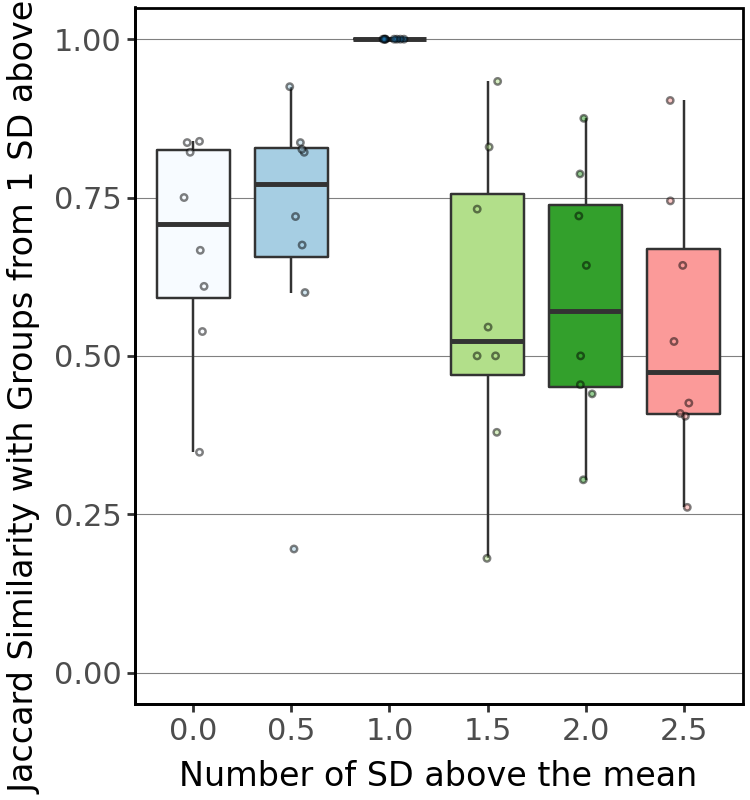

In [15]:
fig = (
ggplot(data=jaccard_values_df, mapping=aes(x="n_sd", y="Value", fill="n_sd")) 
+ geom_boxplot(position=position_dodge(width=0.8), outlier_shape="")
+ geom_jitter(width = 0.15, height=0, size=0.8, alpha=0.5)
# + scale_fill_manual(values=["#F7FBFF", "#A6CEE3", "#1F78B4", "#B2DF8A", "#33A02C", "#FB9A99", "#E31A1C", "#FDBF6F", "#FF7F00", "#CAB2D6", "#6A3D9A"])
+ scale_fill_manual(values=["#F7FBFF", "#A6CEE3", "#1F78B4", "#B2DF8A", "#33A02C", "#FB9A99"])
+ xlab('Number of SD above the mean')
+ ylab('Max. Jaccard Similarity with Groups from 1 SD above the mean')
+ theme_classic() 
+ scale_y_continuous(
        limits=(0, 1),
        breaks=[0, 0.25, 0.5, 0.75, 1]
)
+ theme(panel_grid_major_y=element_line(color="grey", size=0.4),
        panel_grid_minor_y=element_blank(),
        plot_title = element_text(hjust = 0.5,
                                margin={"t": 0, "b": 5, "l": 0, "r": 0},
                                size = 14,
                                face='bold'),
        legend_position = "none",
        axis_title_x = element_text(size = 12),
        axis_title_y = element_text(size = 12),
        axis_text_x = element_text(margin={"t": 2, "b": 2, "l": 0, "r": 0}, size = 11),
        axis_text_y = element_text(margin={"t": 0, "b": 0, "l": 2, "r": 2}, size = 11),
        panel_border = element_rect(color='black'),
        panel_background = element_rect(colour = "black",
                                        linewidth = 1),
        figure_size=(3.75, 4))
)
fig.save(os.path.join(PLOTS_PATH, 'metab_pairwise_cor_jaccard_n_sd_box_plot_unrolled.svg'), format='svg')
fig

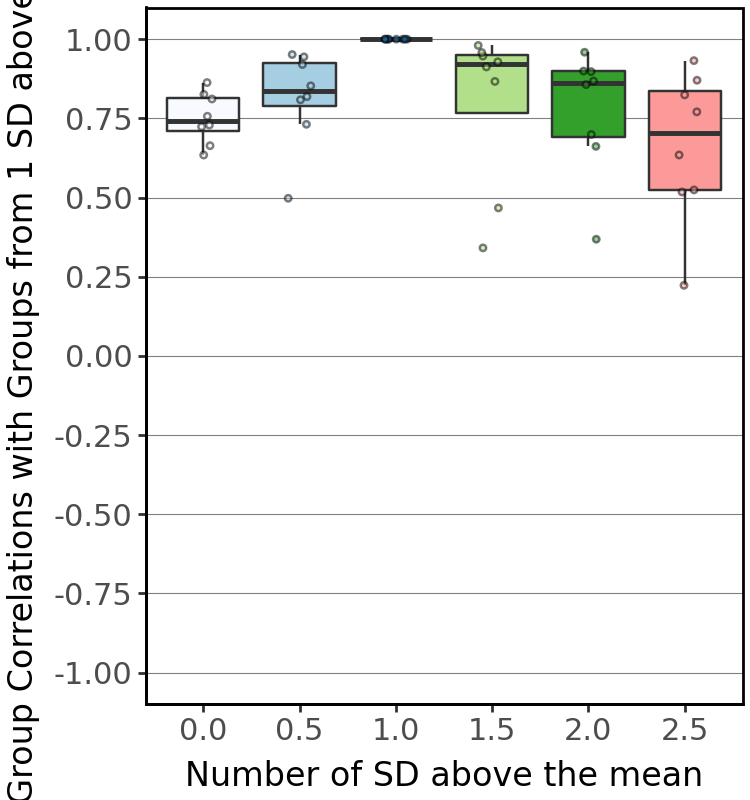

In [14]:
fig = (
ggplot(data=correlation_values_df, mapping=aes(x="n_sd", y="Value", fill="n_sd")) 
+ geom_boxplot(position=position_dodge(width=0.8), outlier_shape="")
+ geom_jitter(width = 0.15, height=0, size=0.8, alpha=0.5)
# + scale_fill_manual(values=["#F7FBFF", "#A6CEE3", "#1F78B4", "#B2DF8A", "#33A02C", "#FB9A99", "#E31A1C", "#FDBF6F", "#FF7F00", "#CAB2D6", "#6A3D9A"])
+ scale_fill_manual(values=["#F7FBFF", "#A6CEE3", "#1F78B4", "#B2DF8A", "#33A02C", "#FB9A99"])
+ xlab('Number of SD above the mean')
+ ylab('Max. Group Correlations with Groups from 1 SD above the mean')
+ theme_classic() 
+ scale_y_continuous(
        limits=(-1, 1),
        breaks=[-1, -0.75, -0.5, -0.25, 0, 0.25, 0.5, 0.75, 1]
)
+ theme(panel_grid_major_y=element_line(color="grey", size=0.4),
        panel_grid_minor_y=element_blank(),
        plot_title = element_text(hjust = 0.5,
                                margin={"t": 0, "b": 5, "l": 0, "r": 0},
                                size = 14,
                                face='bold'),
        legend_position = "none",
        axis_title_x = element_text(size = 12),
        axis_title_y = element_text(size = 12),
        axis_text_x = element_text(margin={"t": 2, "b": 2, "l": 0, "r": 0}, size = 11),
        axis_text_y = element_text(margin={"t": 0, "b": 0, "l": 2, "r": 2}, size = 11),
        panel_border = element_rect(color='black'),
        panel_background = element_rect(colour = "black",
                                        linewidth = 1),
        figure_size=(3.75, 4))
)
fig.save(os.path.join(PLOTS_PATH, 'metab_pairwise_cor_max_cor_n_sd_box_plot_unrolled.svg'), format='svg')
fig

### Metabolite co-membership analysis (threshold)

Run the code below after running the *Pairwise correlation (threshold)* section.

In [55]:
def compute_comembership_matrix(gene_modules, all_metabolites):
    """
    Returns a symmetric boolean matrix where entry (i,j) = True 
    if metabolite i and j are in the same module.
    """
    n = len(all_metabolites)
    metab_to_idx = {m: i for i, m in enumerate(all_metabolites)}
    comembership = np.zeros((n, n), dtype=bool)
    
    for module_metabolites in gene_modules.values():
        idxs = [metab_to_idx[m] for m in module_metabolites if m in metab_to_idx]
        for i, j in combinations(idxs, 2):
            comembership[i, j] = True
            comembership[j, i] = True
    
    return comembership

In [58]:
# Get the union of all metabolites across thresholds
all_metabolites = list(set(
    m for gm in pairwise_correlation_gene_modules_dict.values() 
    for mlist in gm.values() 
    for m in mlist
))

# Compute co-membership matrices
comembership_matrices = {
    n: compute_comembership_matrix(pairwise_correlation_gene_modules_dict[n], all_metabolites)
    for n in threshold_values
}

# Reference co-membership (SD=1)
ref_comembership = comembership_matrices[ref_value]
ref_pairs_mask = np.triu(ref_comembership, k=1)  # upper triangle only, no diagonal

# For each threshold, compute P(same module | same module at SD=1)
recovery_rates = {}
for n in threshold_values:
    other_comembership = comembership_matrices[n]
    
    # Pairs co-assigned at both this threshold and the reference
    both = np.triu(ref_comembership & other_comembership, k=1)
    
    n_ref_pairs = ref_pairs_mask.sum()
    n_recovered = both.sum()
    
    recovery_rates[n] = n_recovered / n_ref_pairs if n_ref_pairs > 0 else np.nan
    print(f"SD={n}: {n_recovered}/{n_ref_pairs} pairs recovered ({100*recovery_rates[n]:.1f}%)")

# Per-pair recovery dataframe for plotting
rows = []
i_upper, j_upper = np.where(ref_pairs_mask)
for n in threshold_values:
    other_comembership = comembership_matrices[n]
    for i, j in zip(i_upper, j_upper):
        rows.append({
            'n_sd': n,
            'pair': f"{all_metabolites[i]}_{all_metabolites[j]}",
            'recovered': int(other_comembership[i, j])
        })

SD=0: 2544/3587 pairs recovered (70.9%)
SD=0.5: 2983/3587 pairs recovered (83.2%)
SD=1: 3587/3587 pairs recovered (100.0%)
SD=1.5: 2384/3587 pairs recovered (66.5%)
SD=2: 2268/3587 pairs recovered (63.2%)
SD=2.5: 1867/3587 pairs recovered (52.0%)


In [59]:
recovery_df = pd.DataFrame(rows)

# Summary: recovery rate per threshold
recovery_summary_df = (
    recovery_df.groupby('n_sd')['recovered']
    .agg(['mean', 'sum', 'count'])
    .reset_index()
    .rename(columns={'mean': 'recovery_rate', 'sum': 'n_recovered', 'count': 'n_ref_pairs'})
)
recovery_summary_df['n_sd'] = recovery_summary_df['n_sd'].astype('category')

In [87]:
recovery_summary_df

,n_sd,recovery_rate,n_recovered,n_ref_pairs
0,0.0,0.709228,2544,3587
1,0.5,0.831614,2983,3587
2,1.0,1.000000,3587,3587
3,1.5,0.664622,2384,3587
4,2.0,0.632283,2268,3587
5,2.5,0.520491,1867,3587


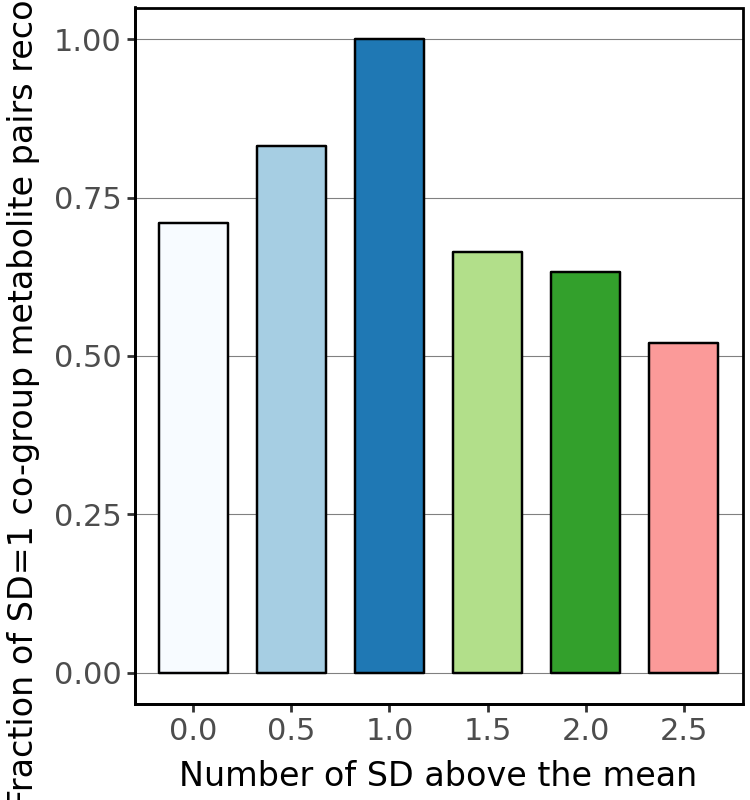

In [66]:
# Plot
fig = (
    ggplot(data=recovery_summary_df, mapping=aes(x='n_sd', y='recovery_rate', fill='n_sd'))
    + geom_col(width=0.7, color='black')
    + scale_fill_manual(values=["#F7FBFF", "#A6CEE3", "#1F78B4", "#B2DF8A", "#33A02C", "#FB9A99"])
    + xlab('Number of SD above the mean')
    + ylab('Fraction of SD=1 co-group metabolite pairs recovered')
    + scale_y_continuous(limits=(0, 1), breaks=[0, 0.25, 0.5, 0.75, 1])
    + theme_classic()
    + theme(panel_grid_major_y=element_line(color="grey", size=0.4),
        panel_grid_minor_y=element_blank(),
        plot_title = element_text(hjust = 0.5,
                                margin={"t": 0, "b": 5, "l": 0, "r": 0},
                                size = 14,
                                face='bold'),
        legend_position = "none",
        axis_title_x = element_text(size = 12),
        axis_title_y = element_text(size = 12),
        axis_text_x = element_text(margin={"t": 2, "b": 2, "l": 0, "r": 0}, size = 11),
        axis_text_y = element_text(margin={"t": 0, "b": 0, "l": 2, "r": 2}, size = 11),
        panel_border = element_rect(color='black'),
        panel_background = element_rect(colour = "black",
                                        linewidth = 1),
        figure_size=(3.75, 4))
)
fig.save(os.path.join(PLOTS_PATH, 'comembership_recovery_by_threshold.svg'), format='svg')
fig

### Confusion heat map analysis

In [12]:
def compute_confusion_matrix(gene_modules_row, gene_modules_col, all_metabolites):
    """
    Computes a confusion matrix where entry (i,j) is the fraction of metabolites
    in module i (row) that also belong to module j (col).
    The matrix is not symmetric: rows sum to 1, columns do not.
    """
    row_keys = list(gene_modules_row.keys())
    col_keys = list(gene_modules_col.keys())
    
    confusion = np.zeros((len(row_keys), len(col_keys)))
    
    for i, key_i in enumerate(row_keys):
        members_i = set(gene_modules_row[key_i])
        for j, key_j in enumerate(col_keys):
            members_j = set(gene_modules_col[key_j])
            overlap = len(members_i & members_j)
            confusion[i, j] = overlap / len(members_i) if len(members_i) > 0 else 0
    
    confusion_df = pd.DataFrame(confusion, index=row_keys, columns=col_keys)
    return confusion_df

In [15]:
def plot_confusion_heatmap(confusion_df, sd_row, sd_col, save_path=None):
    """
    Plots a heatmap of the confusion matrix with annotated fractions.
    Rows correspond to sd_row modules, columns to sd_col modules.
    """
    fig, ax = plt.subplots(figsize=(confusion_df.shape[1] * 0.2 + 1, 
                                     confusion_df.shape[0] * 0.2 + 1))
    
    im = ax.imshow(confusion_df.values, vmin=0, vmax=1, cmap='Blues', aspect='auto')
    
    # Annotate cells
    # for i in range(confusion_df.shape[0]):
    #     for j in range(confusion_df.shape[1]):
    #         val = confusion_df.values[i, j]
    #         text_color = 'white' if val > 0.6 else 'black'
    #         ax.text(j, i, f'{val:.2f}', ha='center', va='center', 
    #                 fontsize=9, color=text_color)
    
    ax.set_xticks(range(confusion_df.shape[1]))
    ax.set_xticklabels([f'G{col.split(' ')[1]}' for col in confusion_df.columns], fontsize=10)
    ax.set_yticks(range(confusion_df.shape[0]))
    ax.set_yticklabels([f'G{row.split(' ')[1]}' for row in confusion_df.index], fontsize=10)
    ax.set_xlabel(f'SD = {sd_col} metabolic groups', fontsize=12)
    ax.set_ylabel(f'SD = {sd_row} metabolic groups', fontsize=12)
    
    # plt.colorbar(im, ax=ax, label='Fraction of row module metabolites')
    # plt.title(f'Module confusion: SD = {sd_row} vs SD = {sd_col}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, format='svg', bbox_inches='tight')
    
    plt.show()

SD = 1 and SD = 0 confision heat map
          Module 1  Module 2  Module 3  Module 4  Module 5  Module 6  \
Module 1  1.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
Module 2  0.121951  0.878049  0.000000  0.000000  0.000000  0.000000   
Module 3  0.000000  0.026316  0.263158  0.657895  0.000000  0.000000   
Module 4  0.000000  0.000000  0.000000  0.000000  0.068966  0.000000   
Module 5  0.000000  0.000000  0.000000  0.000000  0.891304  0.021739   
Module 6  0.000000  0.095238  0.000000  0.000000  0.000000  0.523810   
Module 7  0.000000  0.266667  0.000000  0.000000  0.000000  0.000000   
Module 8  0.000000  0.000000  0.000000  0.272727  0.090909  0.000000   

          Module 7  Module 8  Module 9  Module 10  
Module 1  0.000000  0.000000  0.000000   0.000000  
Module 2  0.000000  0.000000  0.000000   0.000000  
Module 3  0.000000  0.000000  0.052632   0.000000  
Module 4  0.000000  0.896552  0.000000   0.034483  
Module 5  0.000000  0.000000  0.000000   0.000000  
Mo

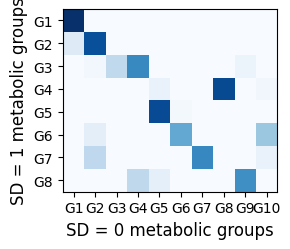

SD = 1 and SD = 0.5 confision heat map
          Module 1  Module 2  Module 3  Module 4  Module 5  Module 6  Module 7
Module 1  0.000000  1.000000  0.000000  0.000000  0.000000  0.000000       0.0
Module 2  0.878049  0.121951  0.000000  0.000000  0.000000  0.000000       0.0
Module 3  0.026316  0.000000  0.973684  0.000000  0.000000  0.000000       0.0
Module 4  0.000000  0.000000  0.000000  0.068966  0.931034  0.000000       0.0
Module 5  0.000000  0.000000  0.000000  0.891304  0.021739  0.000000       0.0
Module 6  0.095238  0.000000  0.000000  0.000000  0.000000  0.904762       0.0
Module 7  0.400000  0.000000  0.000000  0.000000  0.000000  0.000000       0.6
Module 8  0.000000  0.000000  0.181818  0.090909  0.727273  0.000000       0.0


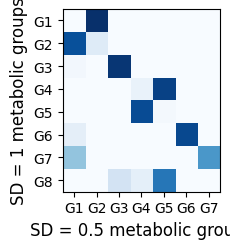

SD = 1 and SD = 1.5 confision heat map
          Module 1  Module 2  Module 3  Module 4  Module 5  Module 6  \
Module 1  0.043478  0.956522  0.000000  0.000000  0.000000  0.000000   
Module 2  0.512195  0.487805  0.000000  0.000000  0.000000  0.000000   
Module 3  0.000000  0.026316  0.789474  0.000000  0.000000  0.000000   
Module 4  0.000000  0.000000  0.000000  0.965517  0.000000  0.034483   
Module 5  0.000000  0.000000  0.000000  0.000000  0.847826  0.130435   
Module 6  0.000000  0.142857  0.000000  0.000000  0.000000  0.000000   
Module 7  0.000000  0.733333  0.200000  0.000000  0.000000  0.000000   
Module 8  0.000000  0.000000  0.000000  0.090909  0.090909  0.818182   

          Module 7  Module 8  
Module 1  0.000000  0.000000  
Module 2  0.000000  0.000000  
Module 3  0.000000  0.184211  
Module 4  0.000000  0.000000  
Module 5  0.000000  0.021739  
Module 6  0.571429  0.000000  
Module 7  0.066667  0.000000  
Module 8  0.000000  0.000000  


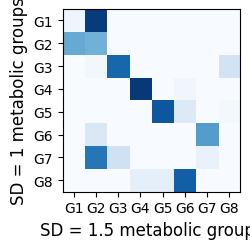

SD = 1 and SD = 2 confision heat map
          Module 1  Module 2  Module 3  Module 4  Module 5  Module 6  \
Module 1  0.043478  0.956522  0.000000  0.000000  0.000000  0.000000   
Module 2  0.512195  0.487805  0.000000  0.000000  0.000000  0.000000   
Module 3  0.000000  0.026316  0.000000  0.815789  0.000000  0.000000   
Module 4  0.000000  0.000000  0.965517  0.000000  0.000000  0.034483   
Module 5  0.000000  0.000000  0.043478  0.000000  0.804348  0.021739   
Module 6  0.000000  0.095238  0.000000  0.047619  0.047619  0.047619   
Module 7  0.000000  0.266667  0.000000  0.200000  0.000000  0.000000   
Module 8  0.000000  0.000000  0.090909  0.000000  0.000000  0.818182   

          Module 7  Module 8  
Module 1  0.000000  0.000000  
Module 2  0.000000  0.000000  
Module 3  0.000000  0.157895  
Module 4  0.000000  0.000000  
Module 5  0.000000  0.021739  
Module 6  0.476190  0.000000  
Module 7  0.066667  0.466667  
Module 8  0.000000  0.000000  


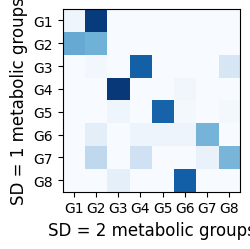

SD = 1 and SD = 2.5 confision heat map
          Module 1  Module 2  Module 3  Module 4  Module 5  Module 6  \
Module 1  0.130435  0.869565  0.000000  0.000000  0.000000  0.000000   
Module 2  0.560976  0.439024  0.000000  0.000000  0.000000  0.000000   
Module 3  0.000000  0.052632  0.000000  0.289474  0.447368  0.000000   
Module 4  0.000000  0.000000  0.965517  0.000000  0.000000  0.000000   
Module 5  0.000000  0.000000  0.021739  0.000000  0.000000  0.760870   
Module 6  0.000000  0.047619  0.000000  0.000000  0.047619  0.047619   
Module 7  0.000000  0.200000  0.000000  0.000000  0.200000  0.000000   
Module 8  0.000000  0.000000  0.090909  0.000000  0.000000  0.000000   

          Module 7  Module 8  Module 9  
Module 1  0.000000  0.000000  0.000000  
Module 2  0.000000  0.000000  0.000000  
Module 3  0.000000  0.131579  0.000000  
Module 4  0.034483  0.000000  0.000000  
Module 5  0.021739  0.021739  0.000000  
Module 6  0.047619  0.000000  0.428571  
Module 7  0.000000  0.400

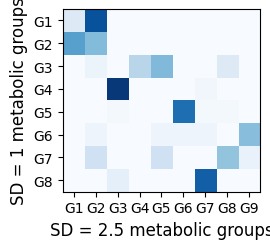

In [18]:
# Get all metabolites
all_metabolites = list(set(
    m for gm in pairwise_correlation_gene_modules_dict.values()
    for mlist in gm.values()
    for m in mlist
))

comparison_pairs = [(1, 0), (1, 0.5), (1, 1.5), (1, 2), (1, 2.5)]

for sd_row, sd_col in comparison_pairs:
    gene_modules_row = pairwise_correlation_gene_modules_dict[sd_row]
    gene_modules_col = pairwise_correlation_gene_modules_dict[sd_col]
    
    confusion_df = compute_confusion_matrix(gene_modules_row, gene_modules_col, all_metabolites)
    
    print(f'SD = {sd_row} and SD = {sd_col} confision heat map')
    print(confusion_df)
    
    plot_confusion_heatmap(
        confusion_df, 
        sd_row=sd_row, 
        sd_col=sd_col,
        # save_path=os.path.join(PLOTS_PATH, f'confusion_heatmap_SD{sd_row}_vs_SD{sd_col}.svg')
    )